In [30]:
import numpy as np 
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [31]:
df = pd.read_excel('Diabetes_and_LifeStyle_Dataset_.csv.xlsx')

In [32]:
display(df.head())

,Age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,52,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1


In [33]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97297 entries, 0 to 97296
Data columns (total 31 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 97297 non-null  int64  
 1   gender                              97297 non-null  object 
 2   ethnicity                           97297 non-null  object 
 3   education_level                     97297 non-null  object 
 4   income_level                        97297 non-null  object 
 5   employment_status                   97297 non-null  object 
 6   smoking_status                      97297 non-null  object 
 7   alcohol_consumption_per_week        97297 non-null  int64  
 8   physical_activity_minutes_per_week  97297 non-null  int64  
 9   diet_score                          97297 non-null  float64
 10  sleep_hours_per_day                 97297 non-null  float64
 11  screen_time_hours_per_day           97297

None

In [34]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Age,97297.0,50.192699,15.492557,19.00,38.00,51.00,61.00,90.00
alcohol_consumption_per_week,97297.0,2.004543,1.418060,0.00,1.00,2.00,3.00,10.00
physical_activity_minutes_per_week,97297.0,118.942886,84.441920,0.00,57.00,100.00,160.00,833.00
diet_score,97297.0,5.995214,1.780096,0.00,4.80,6.00,7.20,10.00
sleep_hours_per_day,97297.0,6.997708,1.093726,3.00,6.30,7.00,7.70,10.00
screen_time_hours_per_day,97297.0,5.997031,2.469805,0.50,4.30,6.00,7.70,16.80
family_history_diabetes,97297.0,0.219657,0.414017,0.00,0.00,0.00,0.00,1.00
hypertension_history,97297.0,0.250912,0.433540,0.00,0.00,0.00,1.00,1.00
cardiovascular_history,97297.0,0.079067,0.269845,0.00,0.00,0.00,0.00,1.00
bmi,97297.0,25.615093,3.588387,15.00,23.20,25.60,28.00,39.20


Text(0.5, 1.0, 'Distribution of Diabetes Stages')

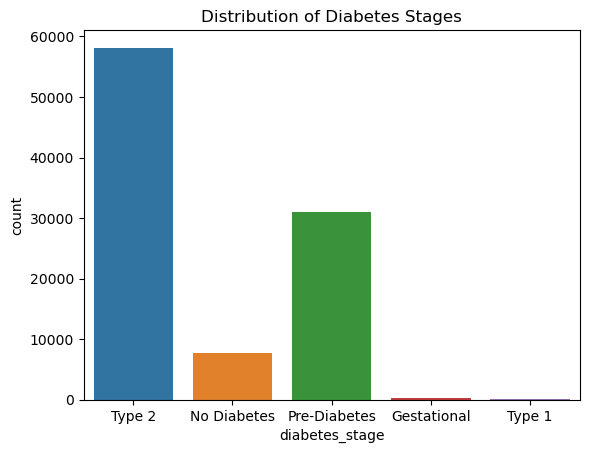

In [46]:
# Distribution of diabetes stages
sns.countplot(x='diabetes_stage', data=df, hue = 'diabetes_stage')
plt.title('Distribution of Diabetes Stages')

<Axes: xlabel='bmi', ylabel='Count'>

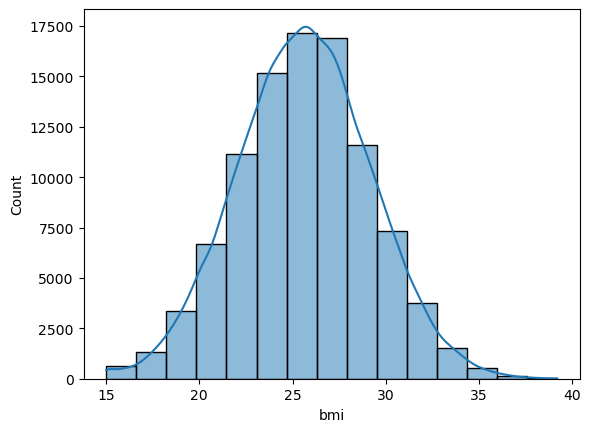

In [22]:
# Histogram for BMI
sns.histplot(df['bmi'], kde=True, bins=15)

<Axes: xlabel='Age', ylabel='Count'>

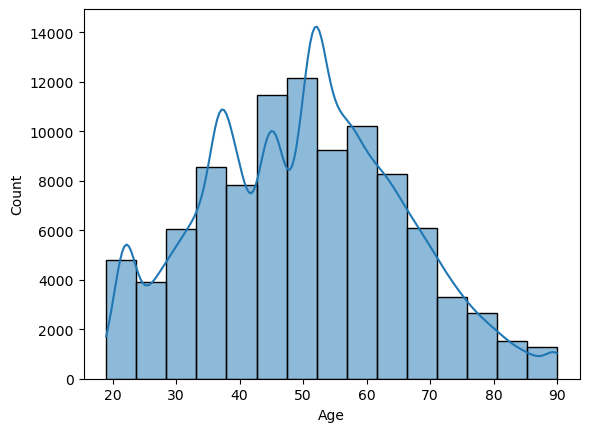

In [23]:
# Histogram for Age
sns.histplot(df['Age'], kde=True, bins=15)

<Axes: xlabel='hba1c', ylabel='Count'>

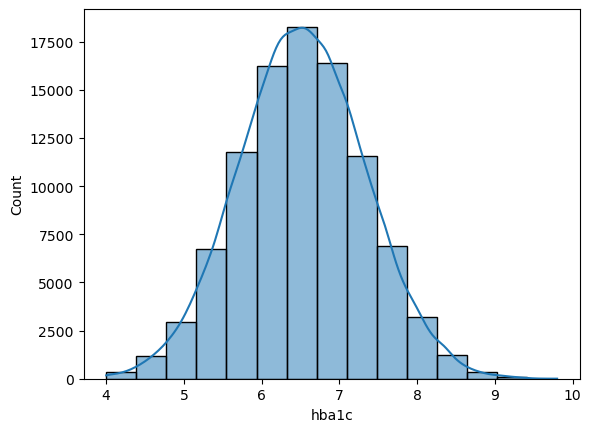

In [24]:
# Histogram for hba1c Levels
sns.histplot(df['hba1c'], kde=True, bins=15)

<Axes: xlabel='physical_activity_minutes_per_week', ylabel='Count'>

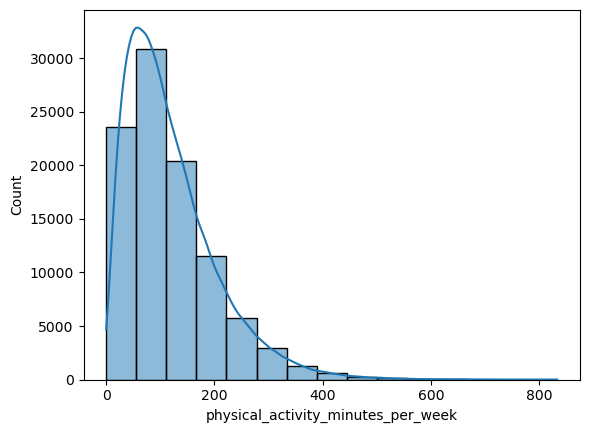

In [25]:
# Histogram for physical_activity_minutes_per_week
sns.histplot(df['physical_activity_minutes_per_week'], kde=True, bins=15)

<Axes: xlabel='diabetes_stage', ylabel='bmi'>

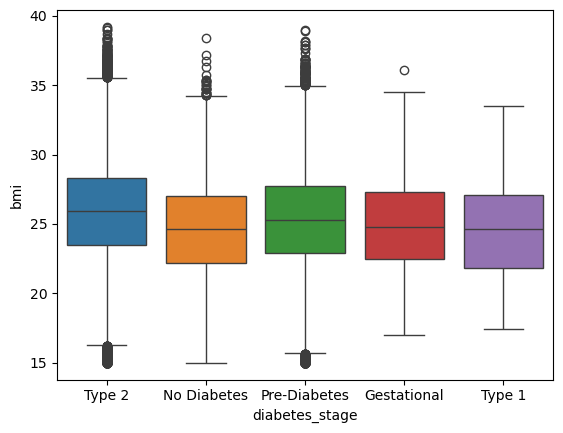

In [45]:
# Box plot - BMI vs Diabetes Stage
sns.boxplot(x='diabetes_stage', y='bmi', data=df, hue='diabetes_stage')

<Axes: xlabel='diabetes_stage', ylabel='cholesterol_total'>

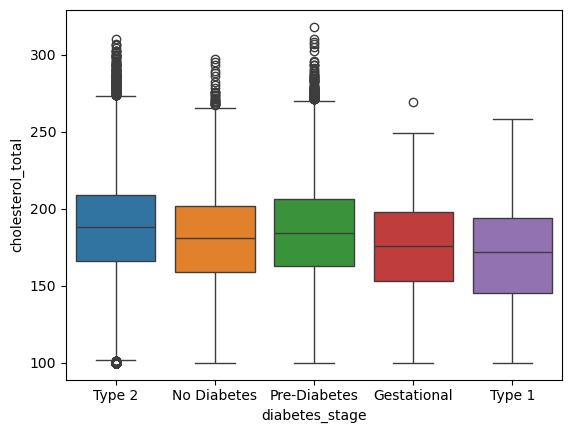

In [44]:
# Box plot - Total Cholesterol vs Diabetes Stage
sns.boxplot(x='diabetes_stage', y='cholesterol_total', data=df, hue='diabetes_stage')

<Axes: xlabel='Age', ylabel='Density'>

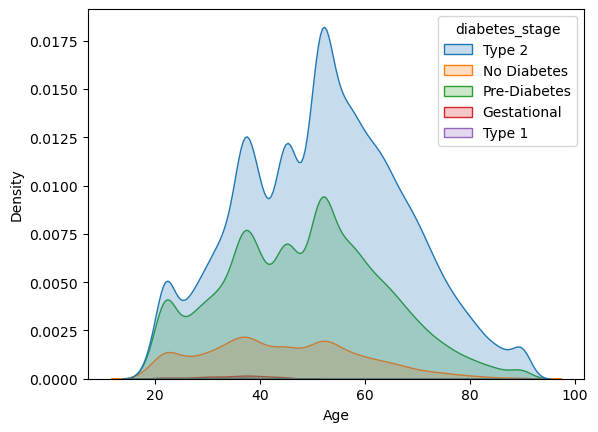

In [28]:
# Age distribution per diabetes stage
sns.kdeplot(data=df, x='Age', hue='diabetes_stage', fill=True)

<Axes: xlabel='diabetes_stage', ylabel='physical_activity_minutes_per_week'>

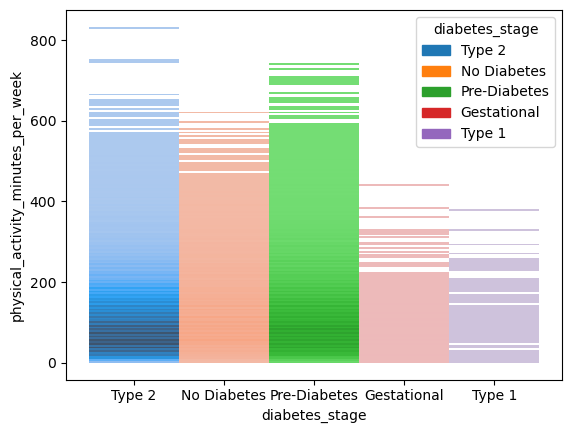

In [50]:
#Correlation between physical activity and Diabetes Stage
sns.histplot(y='physical_activity_minutes_per_week', x='diabetes_stage', data=df, hue='diabetes_stage')

<Axes: xlabel='diabetes_stage', ylabel='insulin_level'>

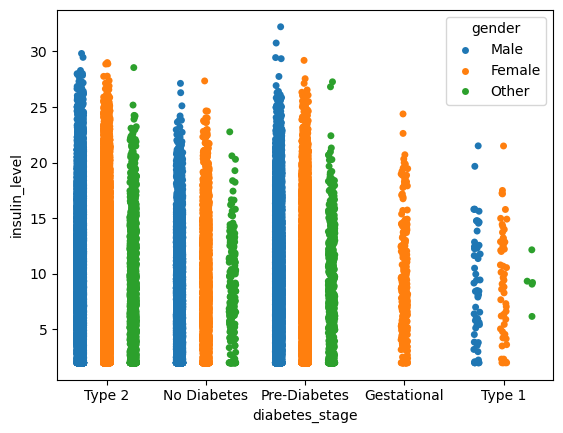

In [57]:
#Insulin level per diabetes stage by Gender
sns.stripplot(x='diabetes_stage', y='insulin_level', data=df, hue='gender', dodge=True)